In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_linnerud
from sklearn.model_selection import train_test_split
plt.style.use('seaborn-v0_8-whitegrid')

In [7]:
# Cell 2: Data Loading and Preparation
print("--- Step 1: Loading the Multivariate Dataset ---")

# Load the Linnerud dataset
linnerud = load_linnerud()

# X matrix: Predictors (Chins, Situps, Jumps)
X_raw = linnerud.data
feature_names = linnerud.feature_names

# Y matrix: Multivariate Responses (Weight, Waist, Pulse)
Y_raw = linnerud.target
target_names = linnerud.target_names

print(f"Original X shape: {X_raw.shape}")
print(f"Original Y shape: {Y_raw.shape} -> Proves this is a Multivariate Regression\n")

# Split into training and testing sets (80/20 split)
X_train_raw, X_test_raw, Y_train, Y_test = train_test_split(
    X_raw, Y_raw, test_size=0.2, random_state=42
)

# Add intercept column (column of 1s) to X matrices
n_train = X_train_raw.shape[0]
n_test = X_test_raw.shape[0]

X_train = np.hstack((np.ones((n_train, 1)), X_train_raw))
X_test = np.hstack((np.ones((n_test, 1)), X_test_raw))

# Update feature names to include Intercept
feature_names_with_intercept = ['Intercept'] + feature_names

print(f"Final X_train shape (with intercept): {X_train.shape}")
print(f"Final Y_train shape: {Y_train.shape}")

--- Step 1: Loading the Multivariate Dataset ---
Original X shape: (20, 3)
Original Y shape: (20, 3) -> Proves this is a Multivariate Regression

Final X_train shape (with intercept): (16, 4)
Final Y_train shape: (16, 3)


In [8]:
# Cell 3: OLS Coefficient Estimation
print("--- Step 2: Estimating the Coefficient Matrix (B_hat) ---")

# Normal Equation: B_hat = (X^T * X)^-1 * X^T * Y
X_T = X_train.T
B_hat = np.linalg.inv(X_T @ X_train) @ X_T @ Y_train

df_B_hat = pd.DataFrame(
    B_hat, 
    index=feature_names_with_intercept, 
    columns=target_names
)

print("Mathematical Formula Applied: B_hat = (X^T X)^-1 X^T Y\n")
print("Estimated Coefficients Matrix:")
display(df_B_hat)

--- Step 2: Estimating the Coefficient Matrix (B_hat) ---
Mathematical Formula Applied: B_hat = (X^T X)^-1 X^T Y

Estimated Coefficients Matrix:


,Weight,Waist,Pulse
Intercept,210.179574,40.920733,52.010869
Chins,0.450329,-0.078208,-0.482767
Situps,-0.318480,-0.048511,0.093215
Jumps,0.091033,0.027973,-0.050086


In [9]:
# Cell 4: Residuals and Error Covariance Matrix
print("--- Step 3: Computing the Error Covariance Matrix ---")

# Predict Y on the training set to find residuals
Y_train_pred = X_train @ B_hat

# Calculate the Error Tensor (E_hat)
E_hat = Y_train - Y_train_pred

# Calculate degrees of freedom: n - (k + 1)
k = X_raw.shape[1] # Number of original predictors
degrees_of_freedom = n_train - (k + 1)

# Estimate the Error Covariance Matrix (Sigma_hat)
# Formula: Sigma_hat = (E_hat^T * E_hat) / df
Sigma_hat = (E_hat.T @ E_hat) / degrees_of_freedom

df_Sigma_hat = pd.DataFrame(
    Sigma_hat, 
    index=target_names, 
    columns=target_names
)

print("This matrix proves the model accounts for the joint correlation between Y variables.")
print("Estimated Error Covariance Matrix (Sigma_hat):")
display(df_Sigma_hat)

--- Step 3: Computing the Error Covariance Matrix ---
This matrix proves the model accounts for the joint correlation between Y variables.
Estimated Error Covariance Matrix (Sigma_hat):


,Weight,Waist,Pulse
Weight,558.151228,49.246986,-60.904194
Waist,49.246986,6.196228,-5.759073
Pulse,-60.904194,-5.759073,59.416654


In [10]:
# Cell 5: Testing and Evaluation
print("--- Step 4: Model Evaluation on Test Set ---")

# 1. Make predictions on the unseen test set
Y_test_pred = X_test @ B_hat

# 2. Calculate R-squared from scratch for each Y dimension
print("R-Squared Scores (Out-of-Sample):")

for i, target in enumerate(target_names):
    # Extract actual and predicted values for the specific dimension
    y_actual = Y_test[:, i]
    y_pred = Y_test_pred[:, i]
    
    # Calculate Total Sum of Squares (SST) and Residual Sum of Squares (SSR)
    y_mean = np.mean(y_actual)
    sst = np.sum((y_actual - y_mean)**2)
    ssr = np.sum((y_actual - y_pred)**2)
    
    # R-squared formula
    r_squared = 1 - (ssr / sst)
    
    print(f"- {target}: {r_squared:.4f}")

--- Step 4: Model Evaluation on Test Set ---
R-Squared Scores (Out-of-Sample):
- Weight: -1.2433
- Waist: -0.0755
- Pulse: -2.7325


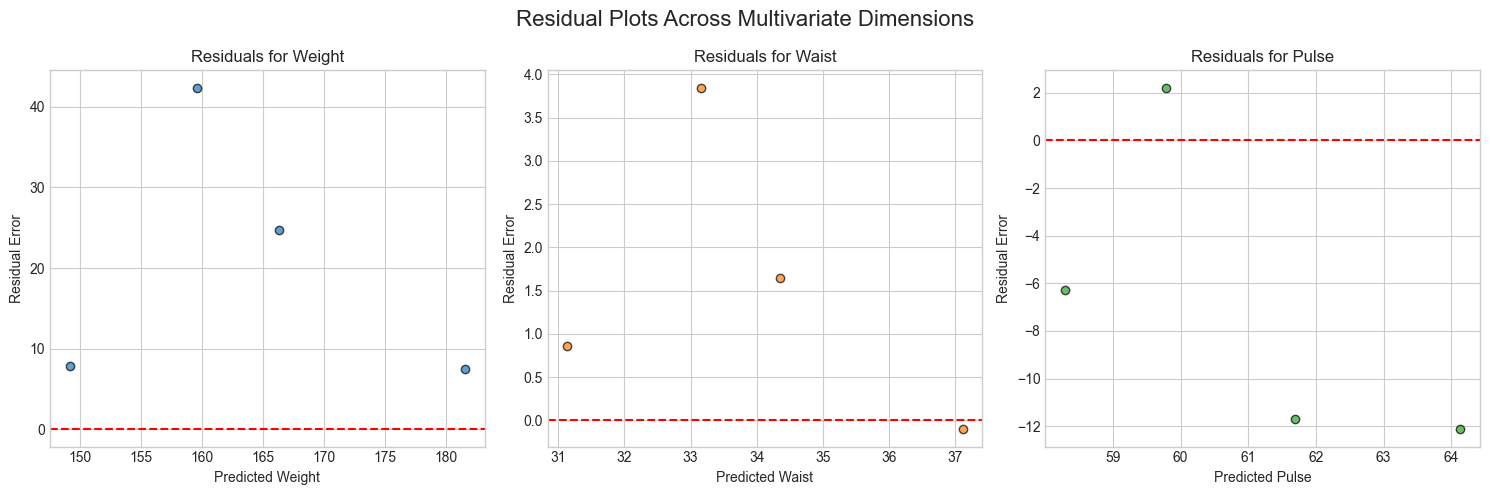

In [11]:
# Cell 6: Visualizing the Multivariate Residuals
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Residual Plots Across Multivariate Dimensions', fontsize=16)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, target in enumerate(target_names):
    y_actual = Y_test[:, i]
    y_pred = Y_test_pred[:, i]
    residuals = y_actual - y_pred
    
    axes[i].scatter(y_pred, residuals, color=colors[i], alpha=0.7, edgecolors='k')
    axes[i].axhline(y=0, color='r', linestyle='--')
    axes[i].set_title(f'Residuals for {target}')
    axes[i].set_xlabel(f'Predicted {target}')
    axes[i].set_ylabel('Residual Error')

plt.tight_layout()
plt.show()